# Basic Image Processing

## 1. Import important libraries

In [1]:
import numpy as np
import cv2
import pywt
import matplotlib
from matplotlib import pyplot as plt
%matplotlib inline

## 2. import image

In [2]:
img = cv2.imread('D:\Akash\ML Project\project-2\images_dataset\maria_sharapova\sharapova-hits-the-practice-courts-and-met-ball-kids.jpg')
img.shape

(555, 700, 3)

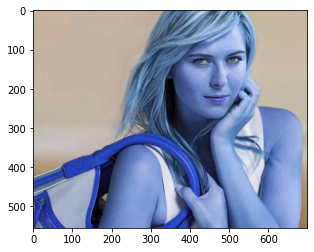

In [3]:
plt.imshow(img)

## 3. change it into gray image

In [4]:
gray = cv2.cvtColor(img , cv2.COLOR_BGR2GRAY)
gray.shape

(555, 700)

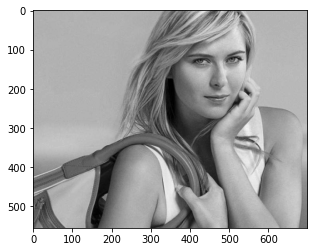

In [5]:
plt.imshow(gray , cmap='gray')

## 4. Detect Eye And Face 

In [6]:
face_cascade = cv2.CascadeClassifier('D:\Akash\ML Project\project-2\haarcascades\haarcascade_frontalface_default.xml')
eye_cascade = cv2.CascadeClassifier('D:\Akash\ML Project\project-2\haarcascades\haarcascade_eye.xml')

faces = face_cascade.detectMultiScale(gray , 1.3 , 5) # it gives dimension of face in whole pic
faces

array([[352,  38, 233, 233]], dtype=int32)

In [7]:
(x,y,w,h) = faces[0]
x,y,w,h

(352, 38, 233, 233)

## 5. Draw rectangle around face and eye

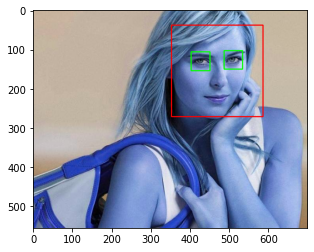

In [8]:
cv2.destroyAllWindows()
for (x,y,w,h) in faces:
     face_img = cv2.rectangle(img,(x,y),(x+w,y+h),(255,0,0),2)
     roi_gray = gray[y:y+h, x:x+w]
     roi_color = img[y:y+h, x:x+w]
     eyes = eye_cascade.detectMultiScale(roi_gray)
     for (ex,ey,ew,eh) in eyes:
         cv2.rectangle(roi_color,(ex,ey),(ex+ew,ey+eh),(0,255,0),2)

plt.figure()
plt.imshow(face_img , cmap='gray')
plt.show()

## 6. Obtain Cropped face 

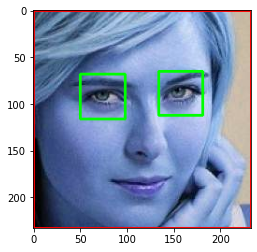

In [9]:
plt.imshow(roi_color, cmap = 'gray')

## 7. Preprocessing: Use wavelet transform as a feature for traning our model

### In wavelet transformed image, you can see edges clearly and that can give us clues on 
### various facial features such as eyes, nose, lips etc

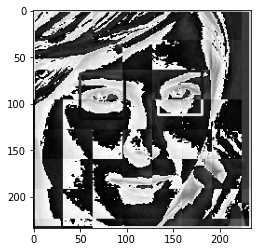

In [10]:
def w2d(img, mode='haar', level=1):
    imArray = img
    #Datatype conversions
    #convert to grayscale
    imArray = cv2.cvtColor( imArray,cv2.COLOR_RGB2GRAY )
    #convert to float
    imArray =  np.float32(imArray)   
    imArray /= 255;
    # compute coefficients 
    coeffs=pywt.wavedec2(imArray, mode, level=level)

    #Process Coefficients
    coeffs_H=list(coeffs)  
    coeffs_H[0] *= 0;  

    # reconstruction
    imArray_H=pywt.waverec2(coeffs_H, mode);
    imArray_H *= 255;
    imArray_H =  np.uint8(imArray_H)

    return imArray_H


im_har = w2d(roi_color,'db1',5)
plt.imshow(im_har, cmap='gray')